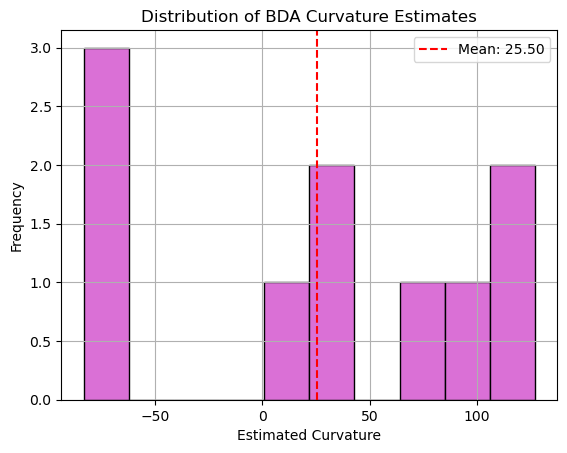

In [21]:
curvatures = []

for _ in range(10):
    # Step 1: Sprinkle
    t = np.random.rand(N)
    x = np.random.rand(N)
    weight = lambda x, t: 1 + 0.5 * np.sin(2 * np.pi * x)
    mask = np.random.rand(N) < weight(x, t)
    if np.count_nonzero(mask) < 10:
        continue  # skip if not enough points

    t = t[mask]
    x = x[mask]
    n_points = len(t)

    # Step 2: Build causal set graph
    G = nx.DiGraph()
    for i in range(n_points):
        G.add_node(i, pos=(x[i], t[i]))
        for j in range(n_points):
            if t[j] > t[i] and (t[j] - t[i])**2 >= (x[j] - x[i])**2:
                G.add_edge(i, j)

    # Step 3: Count intervals
    TC = nx.transitive_closure(G)
    interval_counts = Counter()
    nodes = list(TC.nodes)
    for i in nodes:
        for j in nodes:
            if i != j and TC.has_edge(i, j):
                interval = [
                    k for k in nodes if k != i and k != j and TC.has_edge(i, k) and TC.has_edge(k, j)
                ]
                k_size = len(interval)
                if k_size <= 4:
                    interval_counts[k_size] += 1

    # Step 4: Estimate curvature
    R = sum(coefficients.get(k, 0) * interval_counts[k] for k in range(5))
    R /= l_squared
    curvatures.append(R)

# Plotting
plt.hist(curvatures, bins=10, edgecolor='black', color='orchid')
plt.axvline(np.mean(curvatures), color='red', linestyle='--', label=f"Mean: {np.mean(curvatures):.2f}")
plt.title("Distribution of BDA Curvature Estimates")
plt.xlabel("Estimated Curvature")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()
